✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


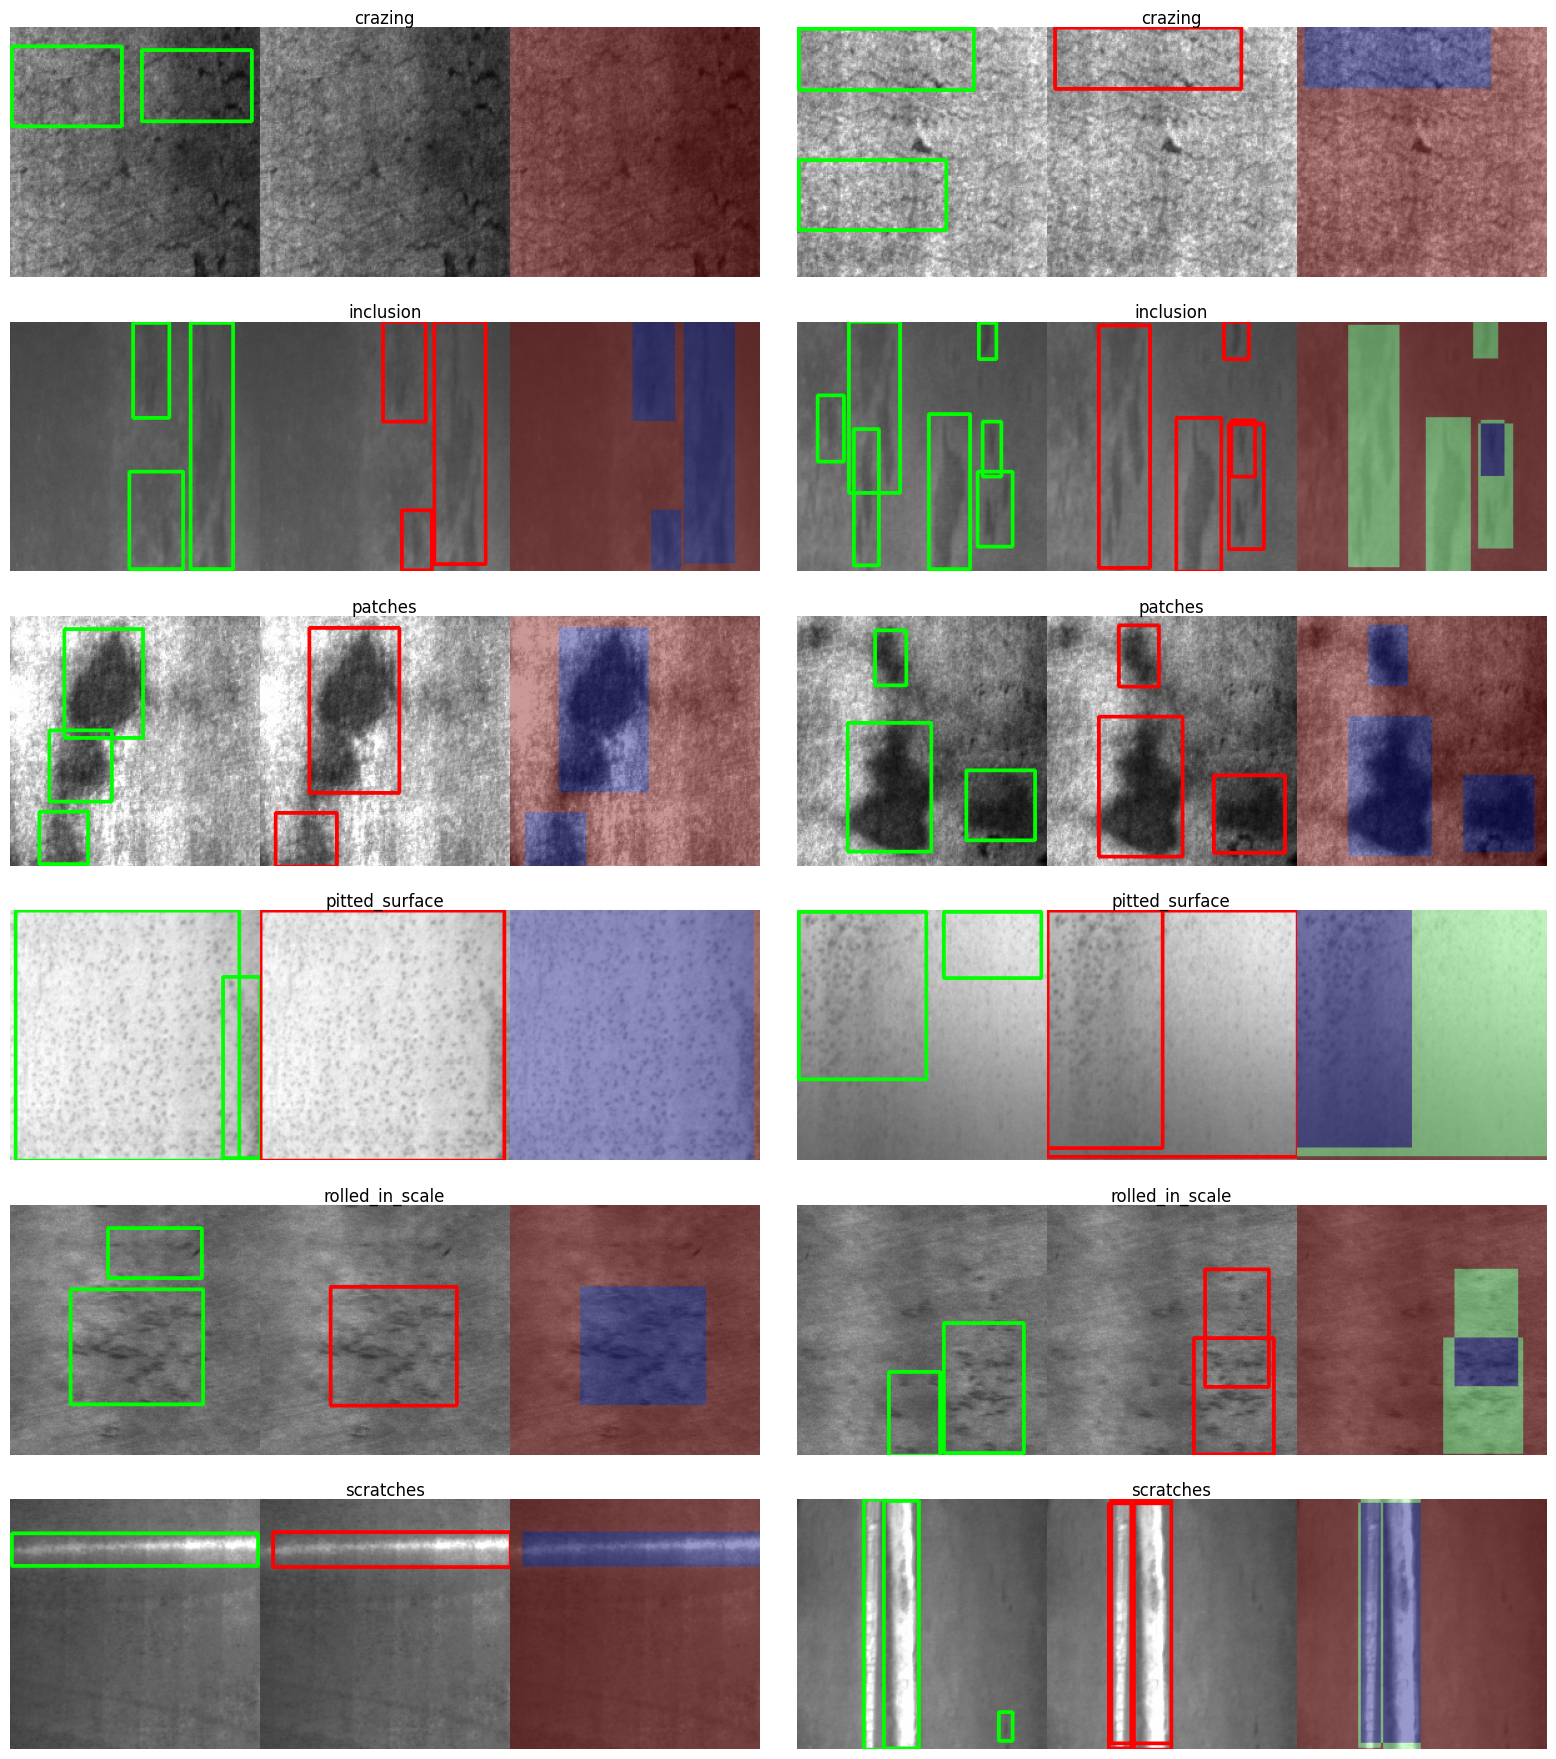

In [2]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\Full_SPDHybrid_NO_Fuse_YOLO_v8n_480px_AdamW_cos_lr_150epochs_seed1\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()


✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


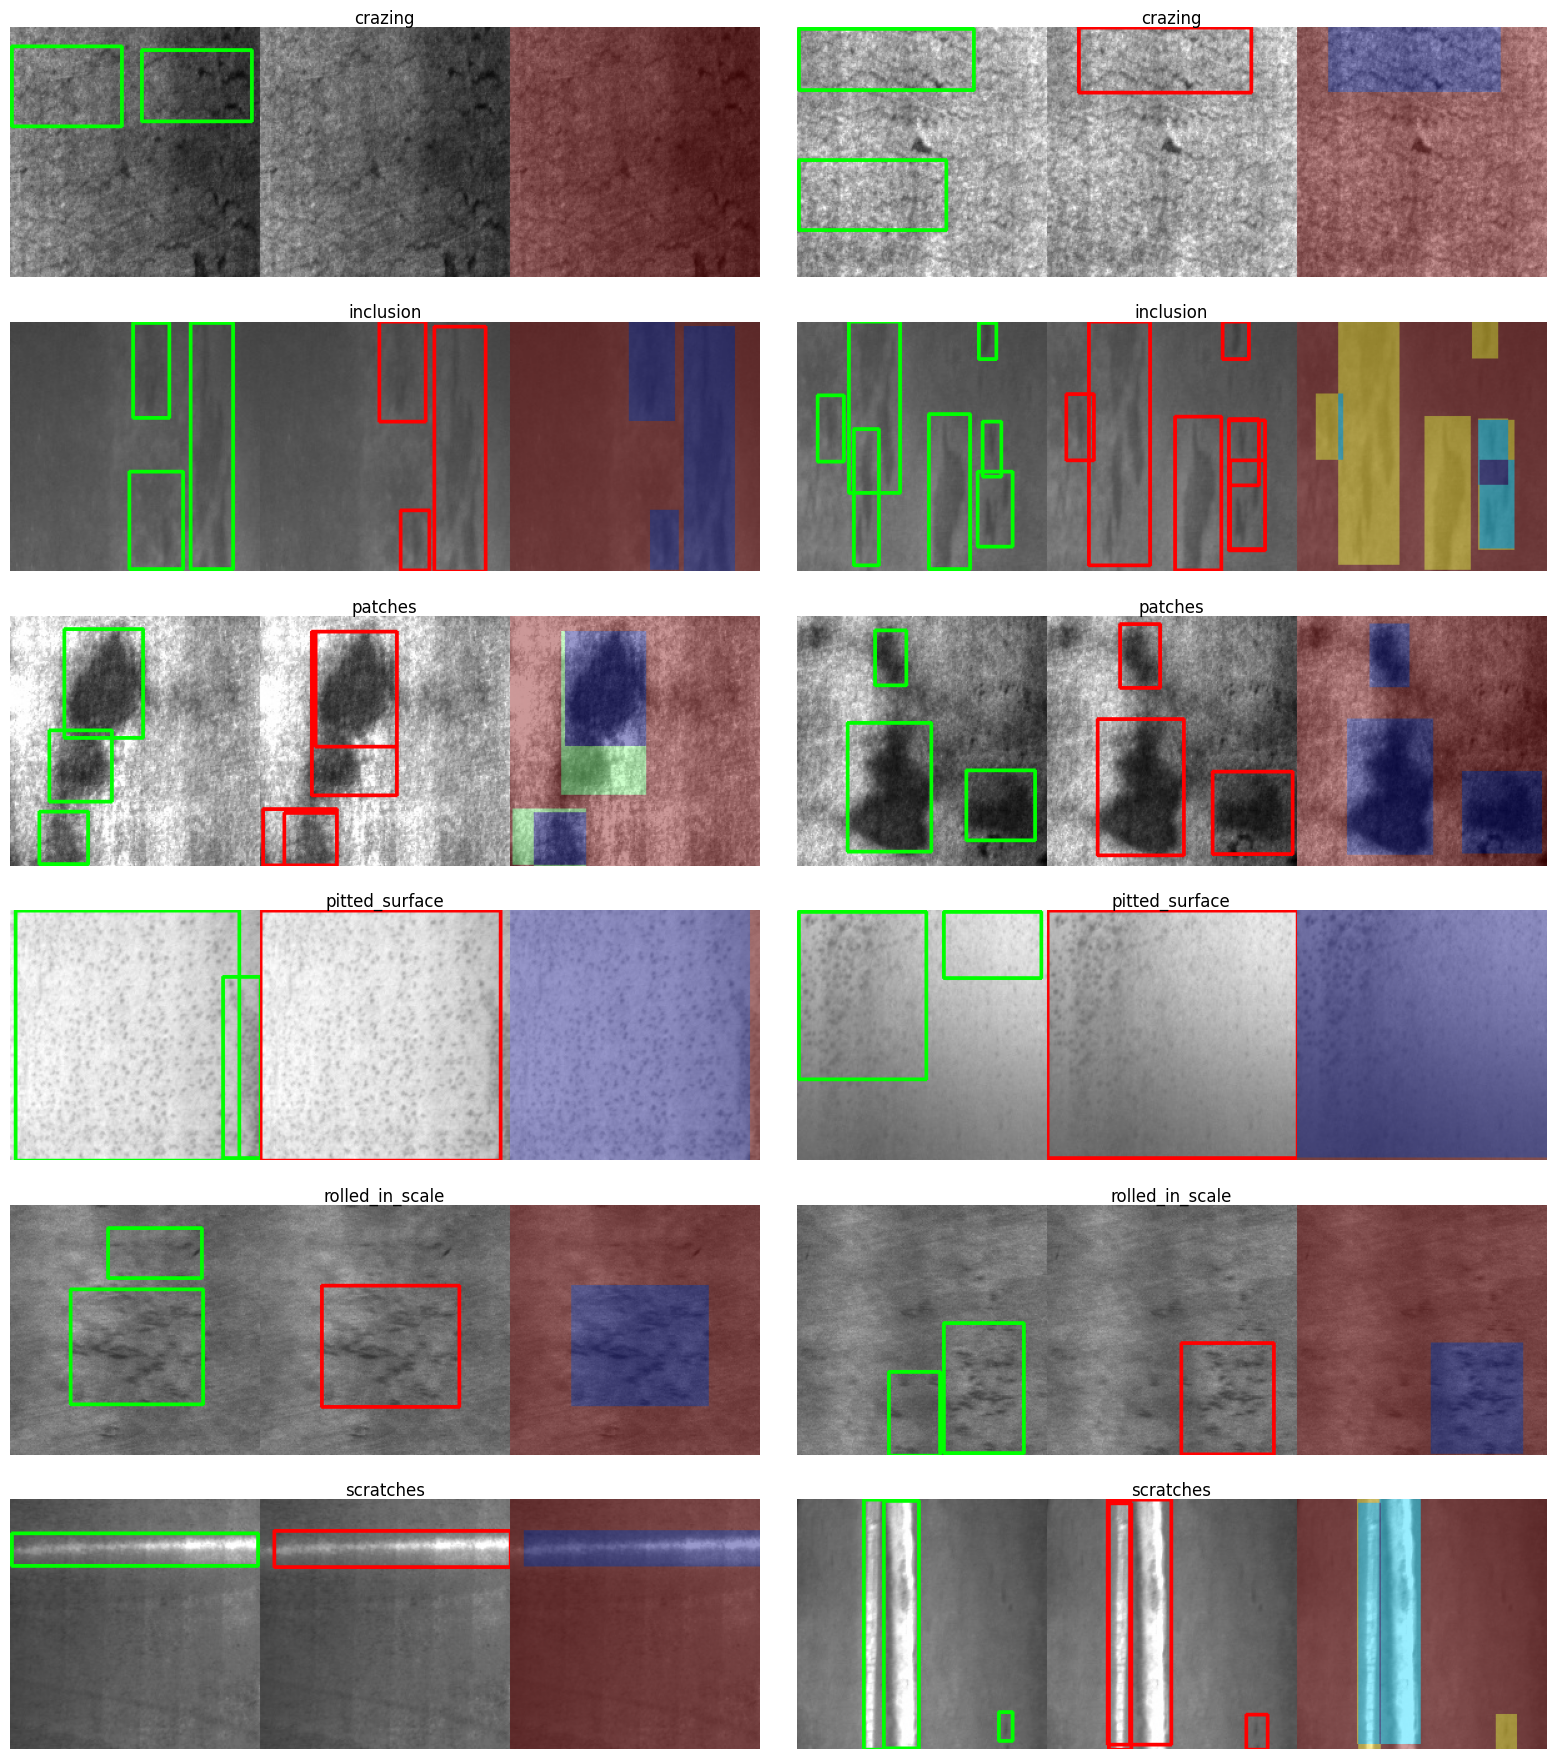

In [9]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\Full_SPDHybrid_with_Fuse_YOLO_v8n_480px_AdamW_cos_lr_150epochs_seed0\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()


✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


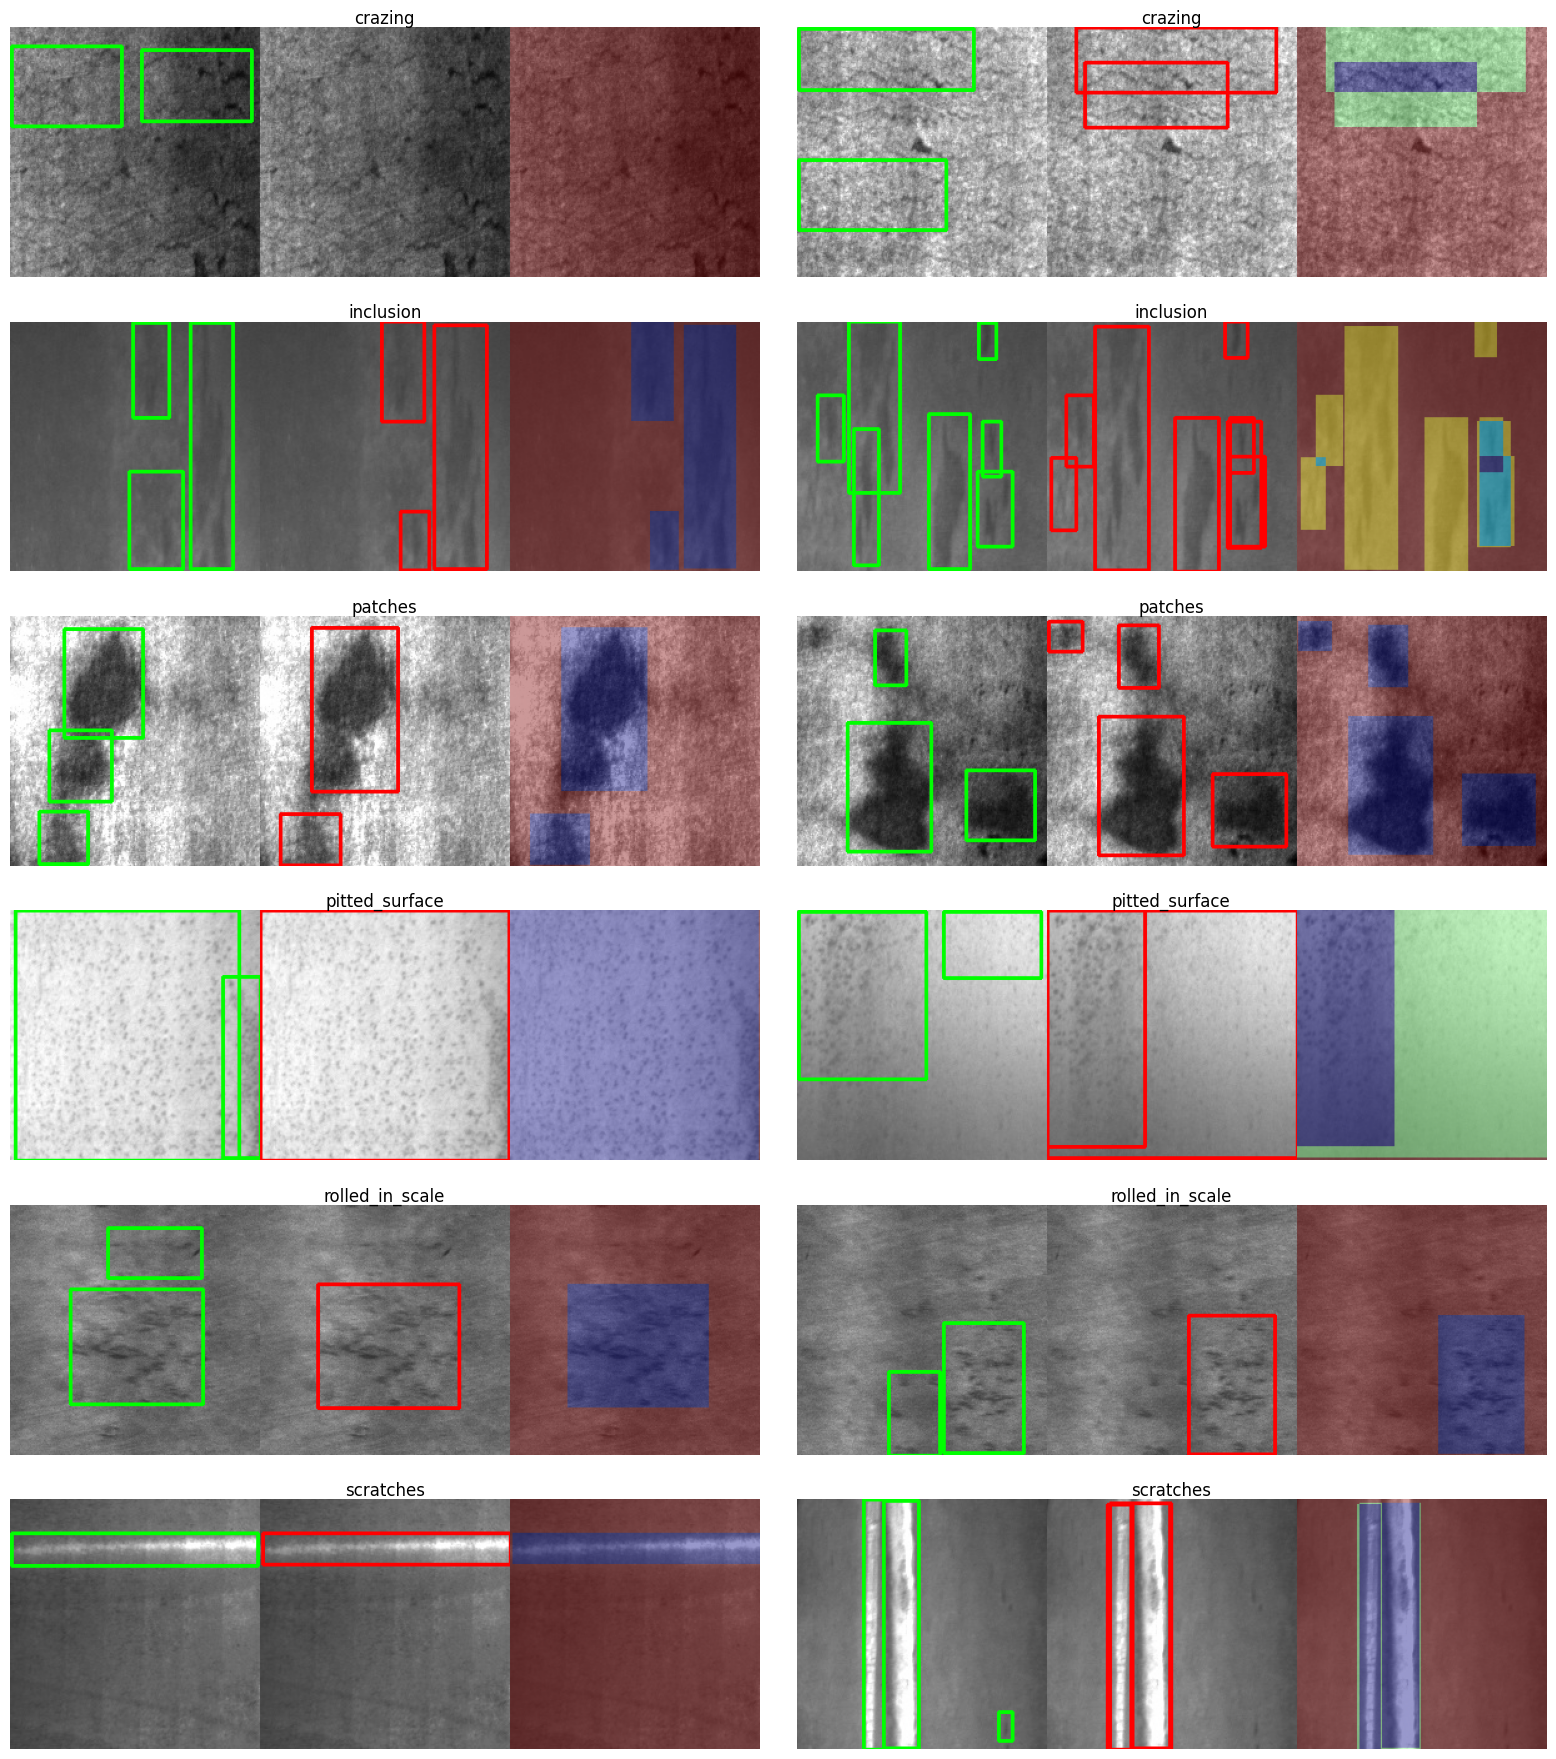

In [6]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\Full_SPDConv__YOLO_v8n_480px_AdamW_cos_lr_150epochs_seed0\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()


✅ Custom modules registered
Model exists: True
Images exist: True
Labels exist: True
Class 0: 2 images
Class 1: 2 images
Class 2: 2 images
Class 3: 2 images
Class 4: 2 images
Class 5: 2 images


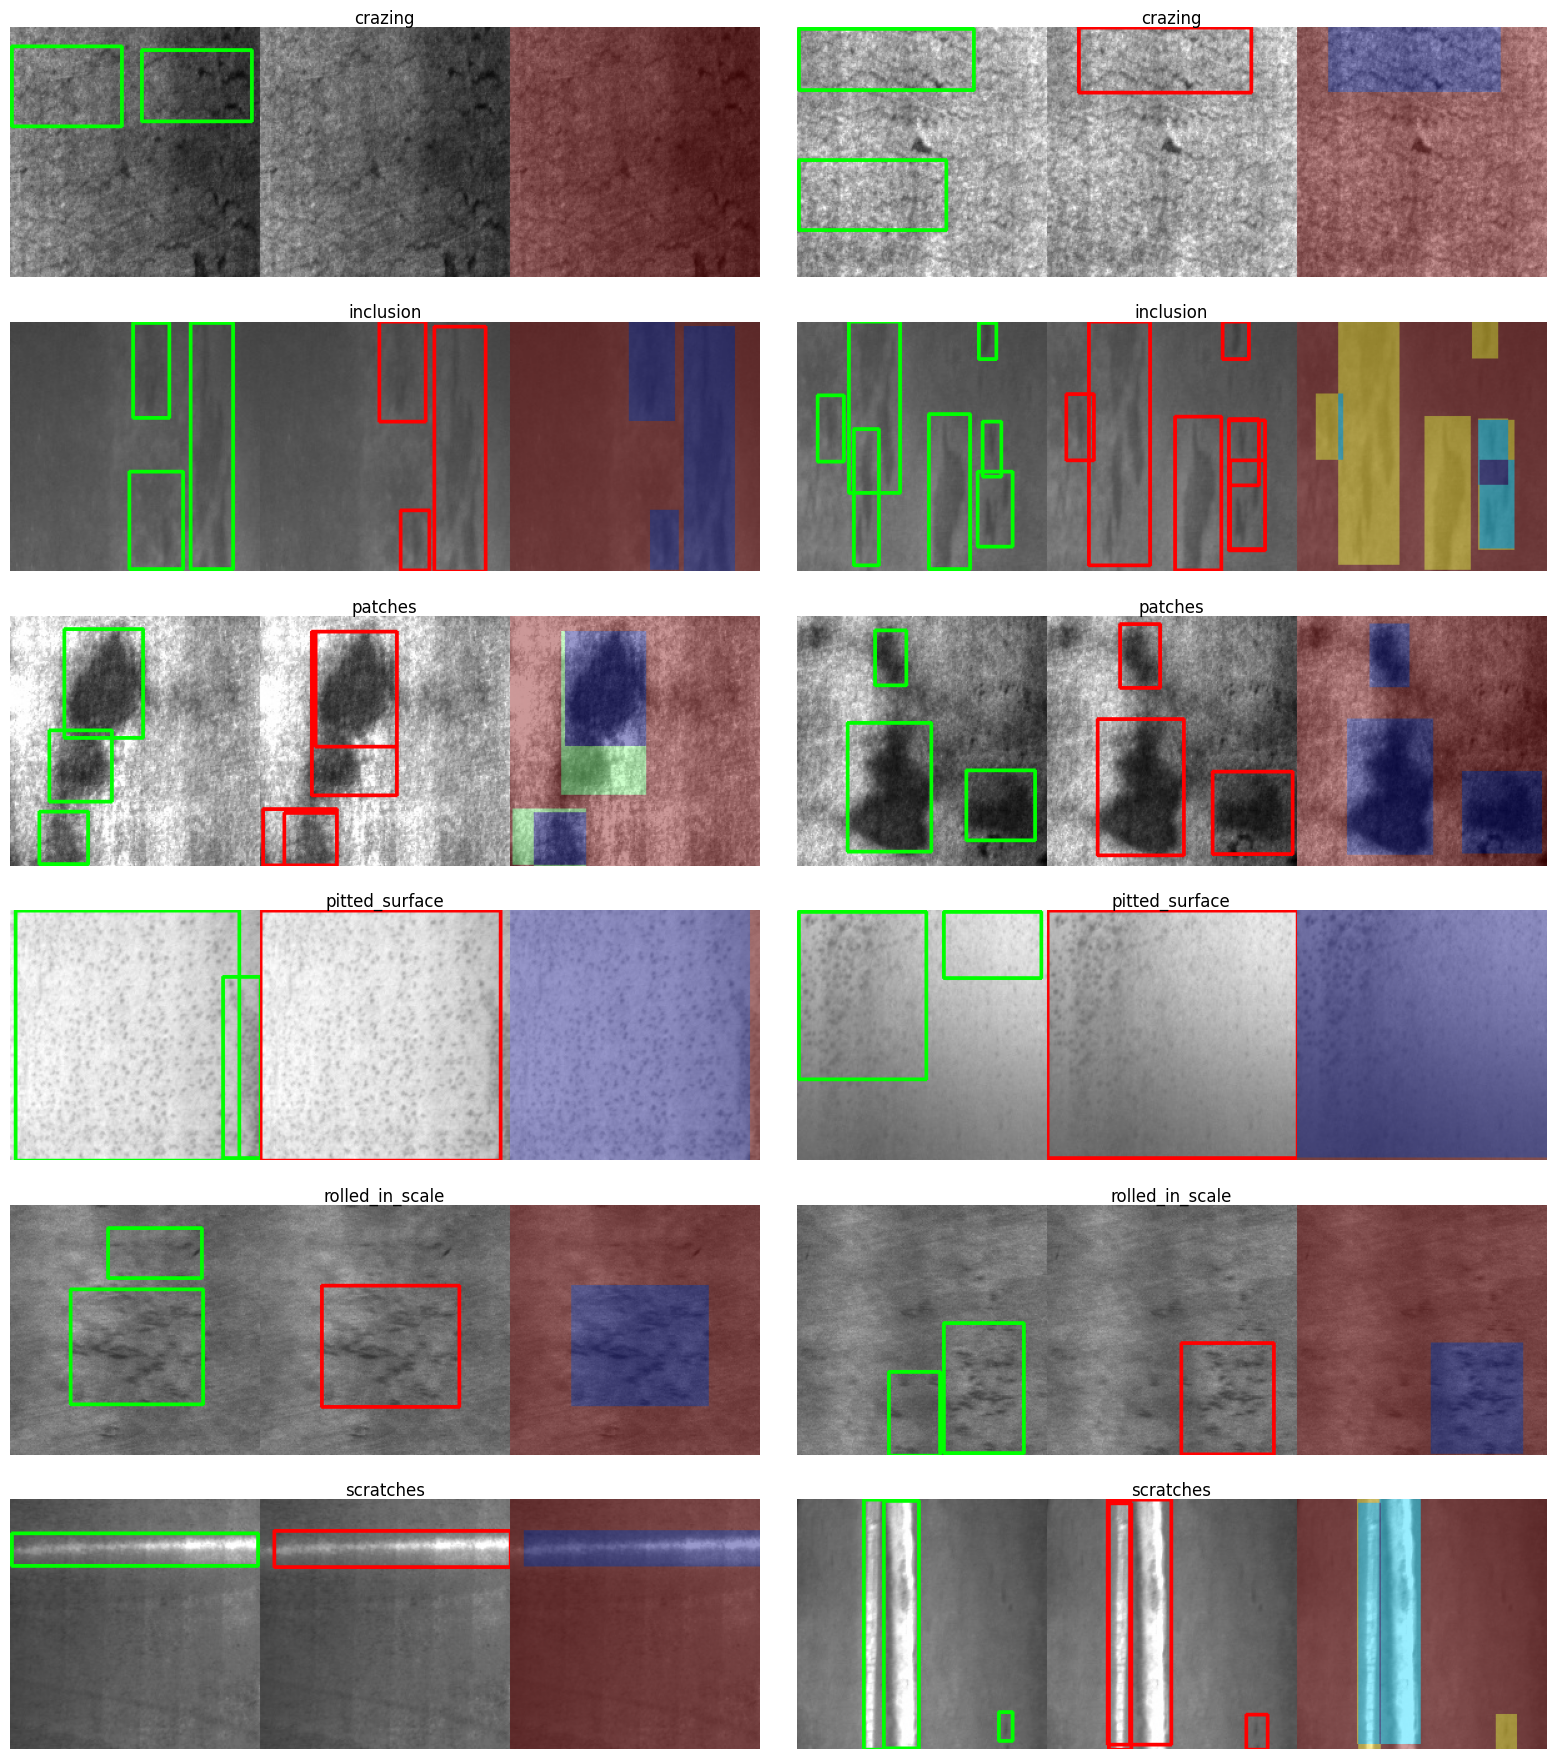

In [8]:
# =========================================================
# 🔥 STEP 1: REGISTER CUSTOM MODULES
# =========================================================
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
    None,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.register_modules import register_custom_modules

register_custom_modules()

print("✅ Custom modules registered")


# =========================================================
# 📦 IMPORTS
# =========================================================
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


# =========================================================
# 📂 PATHS
# =========================================================
best_model_path = r"D:\MY Projects\Steel Defect Detection\runs\detect\experiments\Full_SPDHybrid_with_Fuse_YOLO_v8n_480px_AdamW_cos_lr_150epochs_seed0\weights\best.pt"

data_root = (PROJECT_ROOT / "data/processed_v2").resolve()
data_yaml = (PROJECT_ROOT / "configs/data.yaml").resolve()

print("Model exists:", Path(best_model_path).exists())
print("Images exist:", (data_root / "images/test").exists())
print("Labels exist:", (data_root / "labels/test").exists())


# =========================================================
# 📦 LOAD LABELS
# =========================================================
def load_yolo_labels(label_path, w, h):
    boxes = []
    if not Path(label_path).exists():
        return boxes

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


# =========================================================
# 🎯 DRAW BOXES
# =========================================================
def draw_boxes(img, boxes, color, label):
    img = img.copy()
    for cls, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img


# =========================================================
# 🔥 HEATMAP (ROBUST REPLACEMENT FOR GRAD-CAM)
# =========================================================
def generate_detection_heatmap(img, boxes):
    heatmap = np.zeros(img.shape[:2], dtype=np.float32)

    for _, x1, y1, x2, y2 in boxes:
        heatmap[y1:y2, x1:x2] += 1.0

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)


# =========================================================
# 📸 SAMPLE SELECTION (DOMINANT CLASS)
# =========================================================
def get_samples(data_root, num_per_class=2):
    label_dir = data_root / "labels/test"
    image_dir = data_root / "images/test"

    samples = {i: [] for i in range(6)}

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        if not lines:
            continue

        class_counts = {}
        for line in lines:
            cls = int(line.split()[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

        dominant_class = max(class_counts, key=class_counts.get)

        img = image_dir / (label_file.stem + ".jpg")
        if not img.exists():
            img = image_dir / (label_file.stem + ".png")

        if len(samples[dominant_class]) < num_per_class:
            samples[dominant_class].append(img)

    return samples


# =========================================================
# 🚀 MAIN VISUALIZATION
# =========================================================
def run_visualization():
    yolo = YOLO(best_model_path)

    names = yaml.safe_load(open(data_yaml))["names"]
    samples = get_samples(data_root)

    for k, v in samples.items():
        print(f"Class {k}: {len(v)} images")

    rows = len(names)
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    for cls_id in range(rows):
        imgs = samples.get(cls_id, [])
        for col in range(cols):
            ax = axes[cls_id, col]

            if col >= len(imgs):
                ax.axis("off")
                continue

            img_path = imgs[col]

            img = cv2.imread(str(img_path))
            if img is None:
                ax.axis("off")
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img_rgb.shape[:2]

            # ---- GT ----
            gt_boxes = load_yolo_labels(
                str(img_path)
                .replace("images", "labels")
                .replace(".jpg", ".txt")
                .replace(".png", ".txt"),
                w,
                h,
            )
            gt_img = draw_boxes(img_rgb, gt_boxes, (0, 255, 0), "GT")

            # ---- Prediction ----
            results = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]

            pred_boxes = []
            for b in results.boxes:
                cls = int(b.cls[0])
                x1, y1, x2, y2 = map(int, b.xyxy[0])
                pred_boxes.append((cls, x1, y1, x2, y2))

            pred_img = draw_boxes(img_rgb, pred_boxes, (255, 0, 0), "Pred")

            # ---- Heatmap ----
            cam_img = generate_detection_heatmap(img_rgb, pred_boxes)

            # ---- Combine ----
            combined = np.concatenate([gt_img, pred_img, cam_img], axis=1)

            ax.imshow(combined)
            ax.set_title(names[cls_id], fontsize=12, pad=2)
            ax.axis("off")

    # 🔥 REMOVE ALL EXTRA WHITE SPACE
    plt.subplots_adjust(
        left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.15, wspace=0.05
    )

    plt.show()


# =========================================================
# ▶️ RUN
# =========================================================
run_visualization()
